<a href="https://colab.research.google.com/github/scudilio/MBA---Deep-Learning/blob/main/Aula3_CNN_Gatos_Cachorros_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐱🐶 CNN para Classificação de Imagens Coloridas — Gatos vs Cachorros

## FIAP — MBA em Data Science

---

### Objetivo da Aula

Construir uma **Rede Neural Convolucional (CNN)** do zero para classificar imagens coloridas de **gatos** e **cachorros**, entendendo cada etapa do processo:

1. Como imagens coloridas são representadas numericamente
2. Como carregar e pré-processar imagens de diretórios
3. Data Augmentation — gerando mais dados a partir das imagens existentes
4. Arquitetura da CNN — cada camada e seu papel
5. Treinamento e avaliação
6. Predição de novas imagens

---

## 📚 Revisão Teórica: Como o Computador Enxerga Imagens Coloridas

### Imagem em escala de cinza vs colorida

| Tipo | Canais | Shape | Exemplo |
|------|--------|-------|---------|
| Escala de cinza | 1 canal | (H, W) | Fashion MNIST: (28, 28) |
| Colorida (RGB) | 3 canais | (H, W, 3) | Gatos/Cachorros: (64, 64, 3) |

### O sistema RGB

Cada pixel de uma imagem colorida é composto por **3 valores** (um para cada canal):

- **R (Red)**: intensidade do vermelho (0 a 255)
- **G (Green)**: intensidade do verde (0 a 255)
- **B (Blue)**: intensidade do azul (0 a 255)

Exemplo: o pixel `(255, 0, 0)` é vermelho puro, `(0, 0, 0)` é preto, `(255, 255, 255)` é branco.

### O que muda na CNN?

Para o Fashion MNIST (cinza), o input tinha shape `(28, 28, 1)`. Agora, com imagens coloridas de 64×64, o shape será `(64, 64, 3)`. O **3** indica que temos 3 canais (RGB). Os filtros de convolução agora percorrem as 3 camadas simultaneamente.

### Cálculo do tamanho do input

```
Imagem 64×64 colorida:
64 × 64 × 3 = 12.288 valores por imagem

Comparação com Fashion MNIST:
28 × 28 × 1 = 784 valores por imagem
```

Ou seja, cada imagem de gato/cachorro tem **~16x mais dados** que uma imagem do Fashion MNIST!

---

## 📚 Revisão Teórica: As 4 Etapas da CNN

### Etapa 1 — Convolução

O **filtro (kernel)** de tamanho 3×3 desliza sobre a imagem, multiplicando e somando os valores. Cada filtro detecta um padrão específico (bordas, texturas, formas). Com imagens RGB, o filtro tem shape `(3, 3, 3)` — ele opera nos 3 canais simultaneamente.

A fórmula para o tamanho da saída é:
```
output_size = (input_size - kernel_size) / stride + 1
Exemplo: (64 - 3) / 1 + 1 = 62 → saída 62×62
```

### Etapa 2 — Max Pooling

Reduz a dimensão pegando o **valor máximo** em cada região (geralmente 2×2). Isso torna o modelo mais robusto a variações de posição e reduz o custo computacional.

```
Com pool_size 2×2: 62×62 → 31×31 (metade!)
```

### Etapa 3 — Flattening

Transforma a matriz 3D resultante em um **vetor 1D** para alimentar a rede densa.

### Etapa 4 — Rede Densa (Fully Connected)

Camadas densas fazem a **classificação final**. Para classificação binária (gato vs cachorro), a última camada tem **1 neurônio com ativação Sigmoid**.

```
Sigmoid: saída entre 0 e 1
- Valor < 0.5 → Classe 0 (cachorro)
- Valor ≥ 0.5 → Classe 1 (gato)
```

---

## 1️⃣ Setup: Instalação e Imports

In [ ]:
# ============================================================
# INSTALAÇÃO DO TENSORFLOW
# ============================================================
# Se estiver no Google Colab, descomente a linha abaixo:
# !pip install tensorflow==2.16.1

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

# Bibliotecas básicas
import numpy as np                  # Operações numéricas com arrays
import matplotlib.pyplot as plt     # Visualização de gráficos e imagens
import os                           # Manipulação de diretórios e arquivos
import tempfile                     # Criação de diretórios temporários
import zipfile                      # Extração de arquivos zip

# TensorFlow / Keras — framework de deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential  # Modelo sequencial (empilha camadas)

# Camadas da CNN
from tensorflow.keras.layers import (
    InputLayer,          # Define o shape de entrada
    Conv2D,              # Camada de convolução 2D
    MaxPooling2D,        # Camada de max pooling
    Flatten,             # Transforma matriz em vetor
    Dense,               # Camada totalmente conectada (densa)
    Dropout,             # Regularização: desliga neurônios aleatoriamente
    BatchNormalization   # Normaliza ativações entre camadas
)

# Utilitários para carregar e processar imagens
from tensorflow.keras.preprocessing import image                  # Leitura individual de imagens
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Leitura em lote a partir de diretórios

# Verificando versões
print(f"NumPy:      {np.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")

NumPy:      2.0.2
TensorFlow: 2.19.0
GPU disponível: []


---

## 2️⃣ Carregamento do Dataset

### Estrutura esperada do dataset

O arquivo `dataset.zip` contém a seguinte estrutura de pastas:

```
dataset/
├── training_set/
│   ├── cachorro/       ← imagens .jpg de cachorros (treino)
│   └── gato/           ← imagens .jpg de gatos (treino)
└── test_set/
    ├── cachorro/       ← imagens .jpg de cachorros (teste)
    └── gato/           ← imagens .jpg de gatos (teste)
```

O Keras usa a **estrutura de diretórios** para inferir automaticamente as classes. Cada subpasta é uma classe.

### Por que usar diretório temporário?

Usamos `tempfile.TemporaryDirectory()` para extrair as imagens em um local temporário que será limpo automaticamente ao final da execução, evitando acúmulo de arquivos.

In [ ]:
# ============================================================
# CRIAÇÃO DO DIRETÓRIO TEMPORÁRIO
# ============================================================
# O tempfile cria uma pasta temporária que será apagada automaticamente
# quando a variável temp_dir sair do escopo ou for deletada manualmente

temp_dir = tempfile.TemporaryDirectory()

print(f"Diretório temporário criado em: {temp_dir.name}")

Diretório temporário criado em: /tmp/tmpw6vqjf71


In [ ]:
# ============================================================
# EXTRAÇÃO DO DATASET
# ============================================================
# O zipfile abre o arquivo .zip em modo leitura ('r')
# e extrai todo o conteúdo para o diretório temporário

with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall(temp_dir.name)

print("Dataset extraído com sucesso!")

Dataset extraído com sucesso!


In [ ]:
# ============================================================
# VERIFICAÇÃO DA ESTRUTURA DO DATASET
# ============================================================
# Vamos conferir quantas imagens temos em cada pasta

# Caminhos das pastas
path_treino = f'{temp_dir.name}/dataset/training_set'
path_teste = f'{temp_dir.name}/dataset/test_set'

# Contagem de imagens por classe
for split_name, split_path in [('Treino', path_treino), ('Teste', path_teste)]:
    print(f"\n📂 {split_name}: {split_path}")
    for classe in sorted(os.listdir(split_path)):
        classe_path = os.path.join(split_path, classe)
        if os.path.isdir(classe_path):
            n_imagens = len([f for f in os.listdir(classe_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
            print(f"   {classe}: {n_imagens} imagens")


📂 Treino: /tmp/tmpw6vqjf71/dataset/training_set
   cachorro: 2000 imagens
   gato: 2000 imagens

📂 Teste: /tmp/tmpw6vqjf71/dataset/test_set
   cachorro: 500 imagens
   gato: 500 imagens


---

## 3️⃣ Exploração Visual do Dataset

Antes de construir o modelo, vamos **olhar para os dados**. Em problemas de imagem, isso significa visualizar algumas amostras para entender:

- Qualidade das imagens
- Variação de tamanhos, poses, fundos
- Possíveis problemas (imagens corrompidas, labels errados)

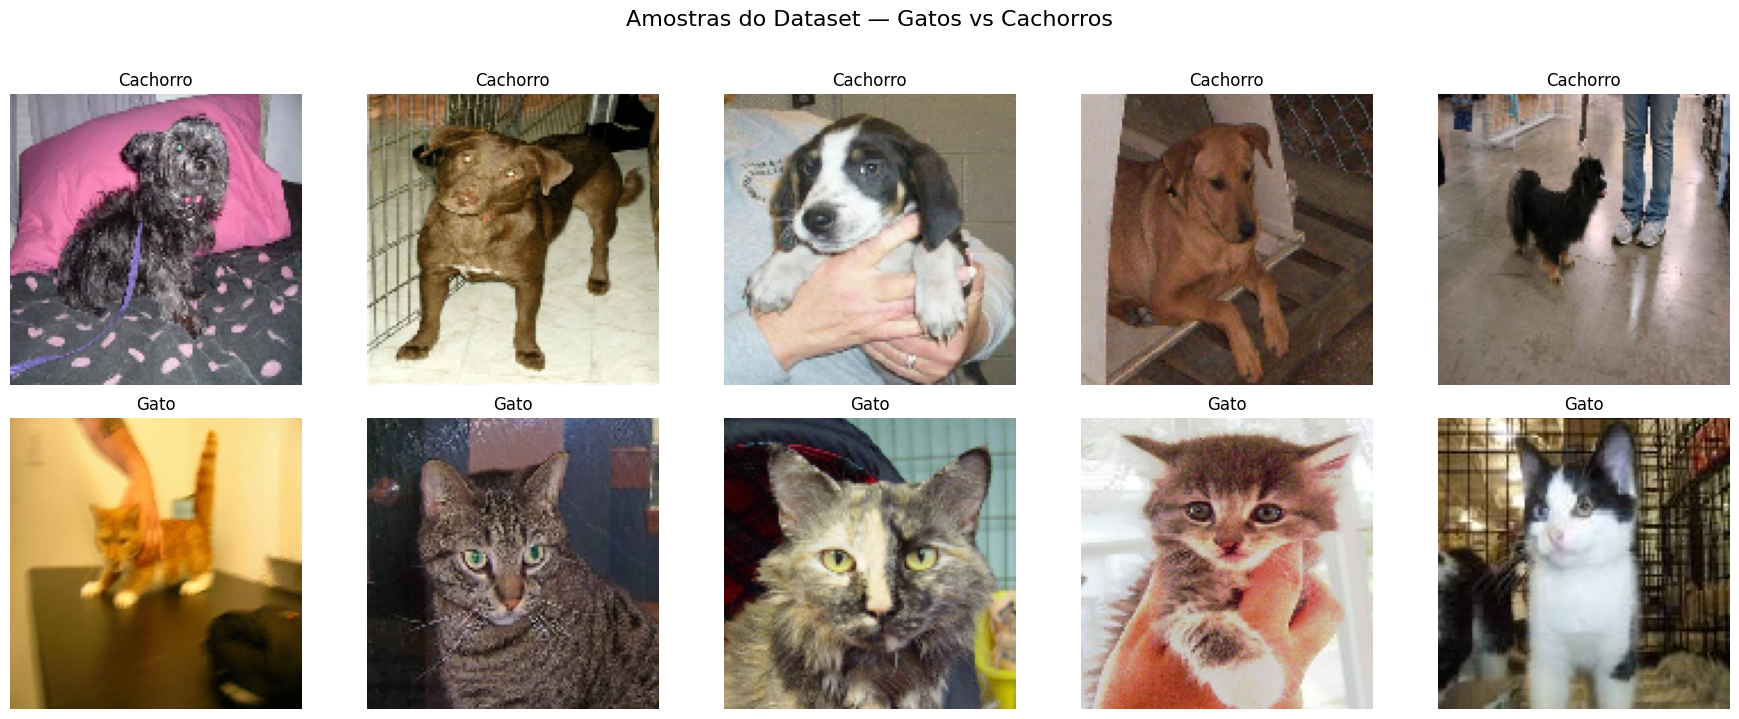

In [ ]:
# ============================================================
# VISUALIZAÇÃO DE AMOSTRAS DO DATASET
# ============================================================
# Exibe 5 imagens de cachorro e 5 de gato para inspeção visual

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for row, classe in enumerate(['cachorro', 'gato']):
    # Lista todos os arquivos da classe
    classe_path = os.path.join(path_treino, classe)
    arquivos = sorted([f for f in os.listdir(classe_path) if f.endswith(('.jpg', '.jpeg', '.png'))])

    for col in range(5):
        # Carrega a imagem usando keras.preprocessing.image
        img_path = os.path.join(classe_path, arquivos[col])
        img = image.load_img(img_path, target_size=(128, 128))  # Redimensiona para visualização

        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{classe.capitalize()}', fontsize=12)
        axes[row, col].axis('off')

plt.suptitle('Amostras do Dataset — Gatos vs Cachorros', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# ANALISANDO UMA IMAGEM EM DETALHE
# ============================================================
# Vamos entender como o computador enxerga uma imagem colorida

# Carrega uma imagem de exemplo
img_exemplo_path = os.path.join(path_treino, 'cachorro',
                                 sorted(os.listdir(os.path.join(path_treino, 'cachorro')))[0])
img_exemplo = image.load_img(img_exemplo_path, target_size=(64, 64))

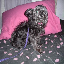

In [ ]:
img_exemplo

In [ ]:


# Converte para array numpy
img_array = image.img_to_array(img_exemplo)

print(f"Tipo do objeto: {type(img_array)}")
print(f"Shape do array: {img_array.shape}")
print(f"  → {img_array.shape[0]} pixels de altura")
print(f"  → {img_array.shape[1]} pixels de largura")
print(f"  → {img_array.shape[2]} canais de cor (R, G, B)")
print(f"Total de valores: {img_array.shape[0]} × {img_array.shape[1]} × {img_array.shape[2]} = {np.prod(img_array.shape):,}")
print(f"\nValores dos pixels variam de {img_array.min():.0f} a {img_array.max():.0f}")

Tipo do objeto: <class 'numpy.ndarray'>
Shape do array: (64, 64, 3)
  → 64 pixels de altura
  → 64 pixels de largura
  → 3 canais de cor (R, G, B)
Total de valores: 64 × 64 × 3 = 12,288

Valores dos pixels variam de 0 a 255


In [ ]:
img_array

array([[[117., 115., 128.],
        [142., 141., 149.],
        [160., 161., 166.],
        ...,
        [151., 153., 165.],
        [138., 140., 152.],
        [134., 137., 146.]],

       [[122., 120., 133.],
        [144., 143., 151.],
        [159., 160., 165.],
        ...,
        [154., 156., 168.],
        [148., 150., 162.],
        [139., 142., 151.]],

       [[128., 126., 139.],
        [143., 142., 150.],
        [165., 166., 171.],
        ...,
        [158., 160., 172.],
        [148., 150., 162.],
        [143., 147., 156.]],

       ...,

       [[169., 162., 230.],
        [102.,  82., 119.],
        [100.,  93., 109.],
        ...,
        [ 81.,  89.,  92.],
        [ 69.,  79.,  81.],
        [ 62.,  72.,  74.]],

       [[ 65.,  74.,  83.],
        [ 80.,  88.,  90.],
        [ 69.,  80.,  76.],
        ...,
        [ 63.,  71.,  74.],
        [ 66.,  76.,  78.],
        [ 57.,  67.,  69.]],

       [[ 72.,  77.,  81.],
        [ 64.,  75.,  77.],
        [ 74.,  

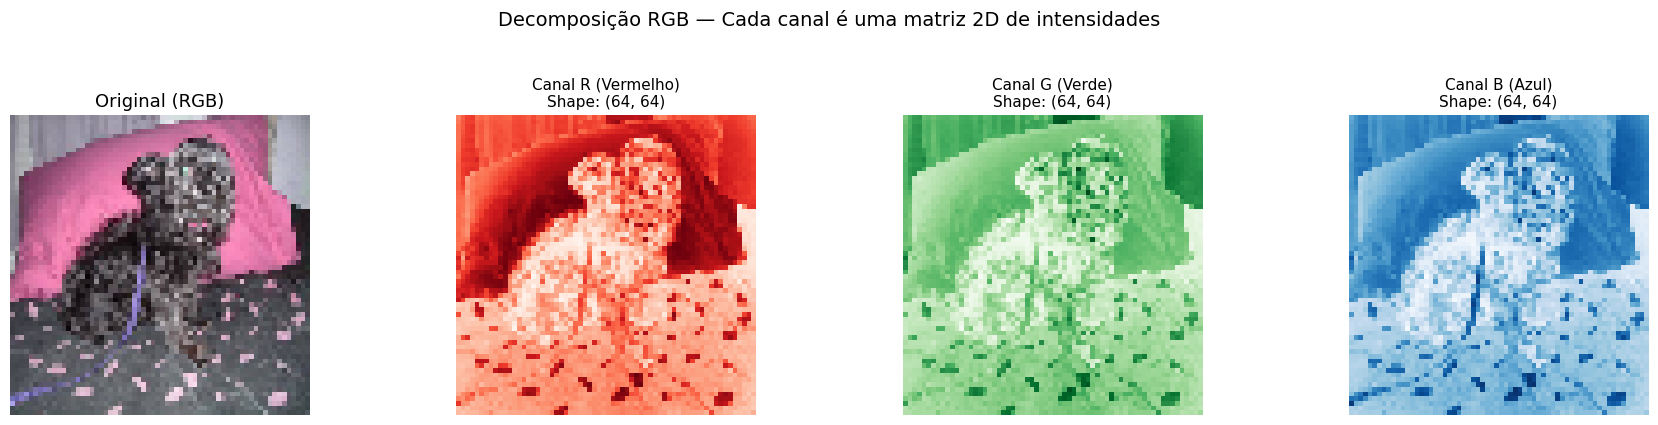

Cada canal é uma matriz 64×64 com valores de 0 (sem cor) a 255 (cor máxima).
A CNN aplica filtros de convolução nos 3 canais SIMULTANEAMENTE.


In [ ]:
# ============================================================
# VISUALIZAÇÃO DOS 3 CANAIS RGB SEPARADOS
# ============================================================
# Cada canal é uma "fatia" da imagem que representa a intensidade
# de uma cor específica (vermelho, verde, azul)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Imagem original (RGB combinado)
axes[0].imshow(img_array.astype('uint8'))
axes[0].set_title('Original (RGB)', fontsize=13)
axes[0].axis('off')

# Cada canal separado
canais = ['Reds', 'Greens', 'Blues']
nomes = ['Canal R (Vermelho)', 'Canal G (Verde)', 'Canal B (Azul)']

for i in range(3):
    # Extrai apenas o canal i (0=R, 1=G, 2=B)
    canal = img_array[:, :, i]
    axes[i+1].imshow(canal, cmap=canais[i])
    axes[i+1].set_title(f'{nomes[i]}\nShape: {canal.shape}', fontsize=11)
    axes[i+1].axis('off')

plt.suptitle('Decomposição RGB — Cada canal é uma matriz 2D de intensidades', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("Cada canal é uma matriz 64×64 com valores de 0 (sem cor) a 255 (cor máxima).")
print("A CNN aplica filtros de convolução nos 3 canais SIMULTANEAMENTE.")

---

## 4️⃣ Pré-processamento e Data Augmentation

### Por que pré-processar?

As imagens originais possuem pixels de 0 a 255. Precisamos **normalizar** para o intervalo [0, 1] dividindo por 255. Isso ajuda o gradiente a convergir mais rápido durante o treinamento.

### O que é Data Augmentation?

**Data Augmentation** é uma técnica para **gerar mais dados de treino** a partir das imagens existentes, aplicando transformações aleatórias como:

| Transformação | Parâmetro | O que faz |
|--------------|-----------|----------|
| `rescale=1./255` | — | Normaliza pixels de [0,255] para [0,1] |
| `rotation_range=7` | Graus | Rotaciona a imagem até 7° |
| `horizontal_flip=True` | — | Espelha horizontalmente (cachorro olhando para esquerda/direita) |
| `shear_range=0.2` | Fração | Cisalhamento (deforma levemente a imagem) |
| `height_shift_range=0.07` | Fração | Desloca a imagem verticalmente até 7% |
| `zoom_range=0.2` | Fração | Aplica zoom de 80% a 120% |

### Por que Data Augmentation ajuda?

- **Aumenta o dataset** sem precisar coletar mais imagens
- **Reduz overfitting** — o modelo vê variações diferentes a cada época
- **Melhora generalização** — o modelo aprende que um gato rotacionado ainda é um gato

### ⚠️ Importante

Data Augmentation é aplicado **SOMENTE no conjunto de treino**. No teste, aplicamos apenas a normalização (`rescale`), pois queremos avaliar o modelo com imagens reais, sem distorções.

In [ ]:
# ============================================================
# GERADOR DE TREINO — com Data Augmentation
# ============================================================
# O ImageDataGenerator aplica transformações ALEATÓRIAS em cada batch
# Isso significa que a cada época o modelo vê imagens ligeiramente diferentes

gerador_treinamento = ImageDataGenerator(
    rescale=1./255,            # NORMALIZAÇÃO: converte [0,255] → [0,1]
    rotation_range=7,          # Rotação aleatória de até 7 graus
    horizontal_flip=True,      # Espelhamento horizontal aleatório
    shear_range=0.2,           # Cisalhamento (deformação leve)
    height_shift_range=0.07,   # Deslocamento vertical de até 7%
    zoom_range=0.2             # Zoom aleatório de 80% a 120%
)

print("Gerador de treino criado com Data Augmentation!")
print("Transformações: rescale, rotation, flip, shear, shift, zoom")

Gerador de treino criado com Data Augmentation!
Transformações: rescale, rotation, flip, shear, shift, zoom


In [ ]:
# ============================================================
# GERADOR DE TESTE — SOMENTE normalização
# ============================================================
# No teste NÃO aplicamos augmentation — queremos avaliar
# o modelo com as imagens originais (sem distorções)

gerador_teste = ImageDataGenerator(
    rescale=1./255  # APENAS normalização, sem transformações
)

print("Gerador de teste criado (somente normalização).")

Gerador de teste criado (somente normalização).


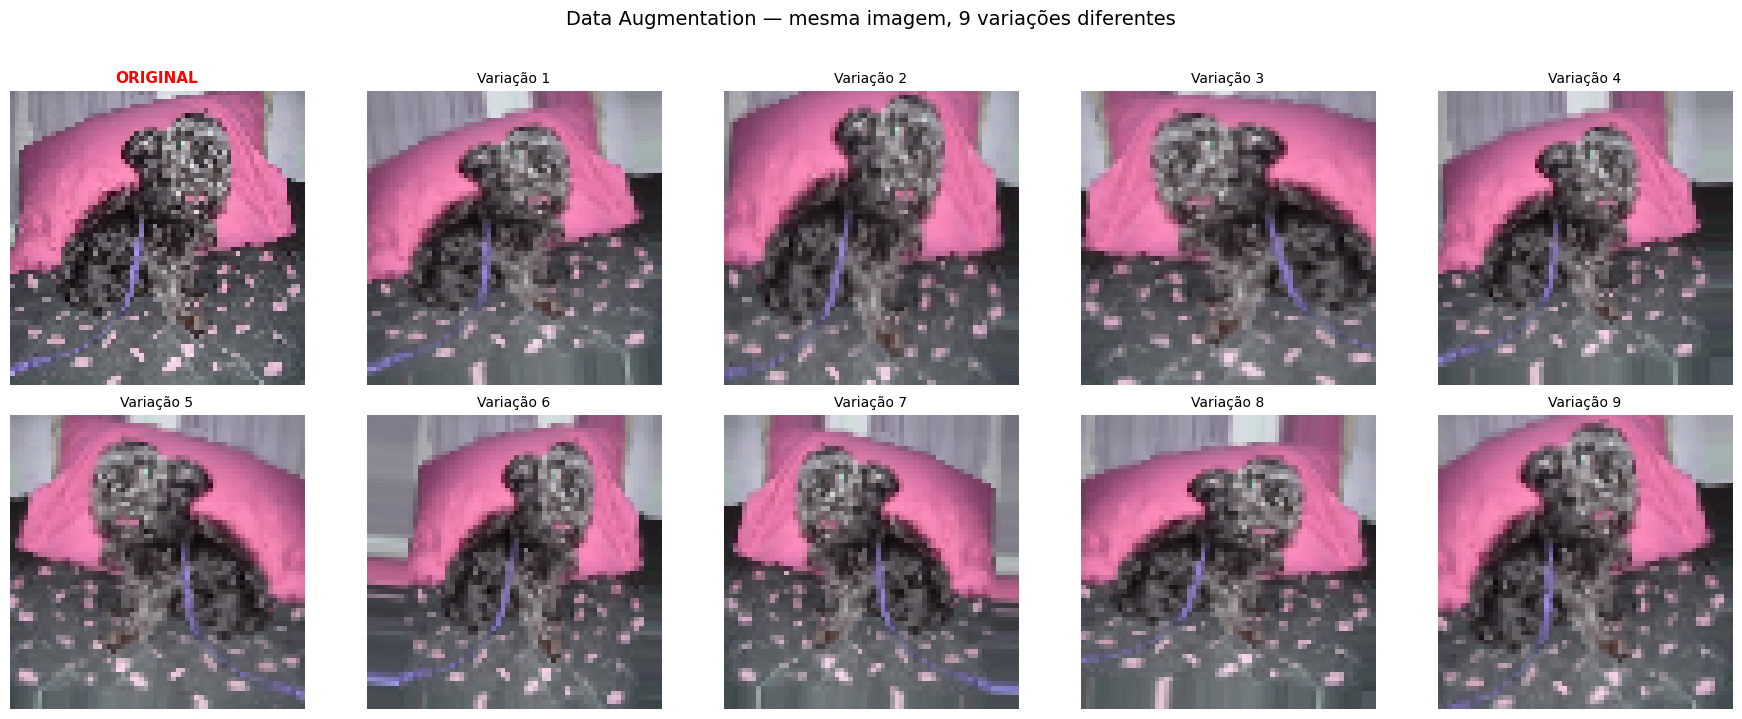

Cada vez que o modelo treina, ele vê variações diferentes da mesma imagem!
Isso reduz overfitting e melhora a generalização.


In [ ]:
# ============================================================
# VISUALIZANDO O EFEITO DO DATA AUGMENTATION
# ============================================================
# Vamos ver como uma MESMA imagem fica após diferentes augmentations

# Carrega uma imagem de exemplo
img_aug = image.load_img(img_exemplo_path, target_size=(64, 64))
img_aug_array = image.img_to_array(img_aug)
img_aug_array = np.expand_dims(img_aug_array, axis=0)  # Adiciona dimensão do batch: (1, 64, 64, 3)

# Cria um gerador temporário para visualização
aug_visual = ImageDataGenerator(
    rotation_range=7, horizontal_flip=True,
    shear_range=0.2, height_shift_range=0.07, zoom_range=0.2
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Primeira imagem: original
axes[0, 0].imshow(img_aug_array[0].astype('uint8'))
axes[0, 0].set_title('ORIGINAL', fontsize=11, fontweight='bold', color='red')
axes[0, 0].axis('off')

# 9 variações augmentadas da MESMA imagem
aug_iter = aug_visual.flow(img_aug_array, batch_size=1)
positions = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3),(1,4)]

for idx, (r, c) in enumerate(positions):
    augmented = next(aug_iter)[0]
    # Clip para garantir range válido [0, 255]
    augmented = np.clip(augmented, 0, 255)
    axes[r, c].imshow(augmented.astype('uint8'))
    axes[r, c].set_title(f'Variação {idx+1}', fontsize=10)
    axes[r, c].axis('off')

plt.suptitle('Data Augmentation — mesma imagem, 9 variações diferentes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Cada vez que o modelo treina, ele vê variações diferentes da mesma imagem!")
print("Isso reduz overfitting e melhora a generalização.")

---

## 5️⃣ Carregamento das Imagens a partir dos Diretórios

### O que o `flow_from_directory` faz?

O método `flow_from_directory` é muito prático:

1. **Lê as imagens** de cada subpasta automaticamente
2. **Infere as classes** pelo nome das subpastas (cachorro, gato)
3. **Redimensiona** todas as imagens para o `target_size` definido (64×64)
4. **Carrega em batches** de tamanho `batch_size` (32 por vez, não carrega tudo na memória)
5. **Aplica as transformações** do `ImageDataGenerator` em tempo real

### Parâmetros importantes

- `target_size=(64, 64)`: redimensiona todas as imagens para 64×64 pixels
- `batch_size=32`: processa 32 imagens por vez
- `class_mode='binary'`: classificação binária (0 = cachorro, 1 = gato)

In [ ]:
# ============================================================
# CARREGAMENTO DOS DADOS DE TREINO
# ============================================================
# flow_from_directory lê imagens das pastas e cria um gerador
# que entrega batches de (imagens, labels) durante o treinamento

base_treinamento = gerador_treinamento.flow_from_directory(
    f'{temp_dir.name}/dataset/training_set',  # Caminho raiz com as subpastas das classes
    target_size=(64, 64),   # Todas as imagens são redimensionadas para 64×64
    batch_size=32,          # Processa 32 imagens por vez (não carrega tudo na RAM)
    class_mode='binary'     # Classificação binária: 0 ou 1
)

# O Keras detectou automaticamente as classes pelas subpastas!

Found 4000 images belonging to 2 classes.


In [ ]:
# ============================================================
# CARREGAMENTO DOS DADOS DE TESTE
# ============================================================
# Mesma estrutura, mas usando o gerador SEM augmentation

base_teste = gerador_teste.flow_from_directory(
    f'{temp_dir.name}/dataset/test_set',  # Caminho do conjunto de teste
    target_size=(64, 64),   # Mesmo tamanho que o treino (OBRIGATÓRIO)
    batch_size=32,          # Batch size
    class_mode='binary'     # Classificação binária
)

Found 1000 images belonging to 2 classes.


In [ ]:
# ============================================================
# VERIFICAÇÃO: Mapeamento das classes
# ============================================================
# O Keras atribui automaticamente um índice numérico para cada classe
# O mapeamento é feito em ordem ALFABÉTICA dos nomes das pastas

print("Mapeamento das classes:")
print(base_treinamento.class_indices)
print("\n→ cachorro = 0, gato = 1")
print("→ Se o modelo prediz < 0.5, é CACHORRO")
print("→ Se o modelo prediz ≥ 0.5, é GATO")

Mapeamento das classes:
{'cachorro': 0, 'gato': 1}

→ cachorro = 0, gato = 1
→ Se o modelo prediz < 0.5, é CACHORRO
→ Se o modelo prediz ≥ 0.5, é GATO


---

## 6️⃣ Construção da Arquitetura da CNN

### Visão geral da arquitetura

```
Input (64×64×3)
    ↓
Conv2D(32 filtros, 3×3, ReLU)  →  Extrai 32 mapas de características
BatchNormalization              →  Normaliza ativações (estabiliza treino)
MaxPooling2D(2×2)              →  Reduz dimensão pela metade
    ↓
Conv2D(32 filtros, 3×3, ReLU)  →  Extrai padrões mais complexos
BatchNormalization              →  Normaliza ativações
MaxPooling2D(2×2)              →  Reduz dimensão novamente
    ↓
Flatten                        →  Transforma em vetor 1D
    ↓
Dense(128, ReLU)               →  Camada oculta 1
Dropout(0.2)                   →  Desliga 20% dos neurônios (anti-overfitting)
Dense(128, ReLU)               →  Camada oculta 2
Dropout(0.2)                   →  Desliga 20% dos neurônios
    ↓
Dense(1, Sigmoid)              →  Saída: probabilidade de ser gato
```

### Sobre o BatchNormalization

O **BatchNormalization** normaliza as saídas de cada camada para média ~0 e desvio ~1. Benefícios:
- Treinamento mais **estável** e **rápido**
- Permite usar **learning rates maiores**
- Atua como uma leve **regularização**

### Sobre o Dropout

O **Dropout(0.2)** desliga aleatoriamente 20% dos neurônios a cada batch de treinamento. Isso força a rede a não depender de neurônios específicos, **reduzindo overfitting**.

### Por que Sigmoid na última camada?

Para classificação **binária** (2 classes), usamos:
- **1 neurônio** na última camada
- **Sigmoid** como ativação → saída entre 0 e 1
- **binary_crossentropy** como loss

Se fosse multiclasse (3+ classes), usaríamos:
- **N neurônios** (1 por classe)
- **Softmax** como ativação
- **categorical_crossentropy** como loss

In [ ]:
# ============================================================
# CONSTRUÇÃO DO MODELO CNN
# ============================================================
# Modelo Sequential: empilha camadas na ordem que definimos

classificador = Sequential()

# --- CAMADA DE ENTRADA ---
# Define o formato esperado: imagem 64×64 com 3 canais (RGB)
classificador.add(InputLayer(shape=(64, 64, 3)))

# --- BLOCO CONVOLUCIONAL 1 ---
# Conv2D: 32 filtros de 3×3, ativação ReLU
# Saída: (62, 62, 32) → 64-3+1=62 pixels, 32 feature maps
classificador.add(Conv2D(32, (3, 3), activation='relu'))

# BatchNormalization: normaliza as ativações (estabiliza o treinamento)
#classificador.add(BatchNormalization())

# MaxPooling2D: reduz dimensão pela metade com janela 2×2
# Saída: (31, 31, 32)
classificador.add(MaxPooling2D(pool_size=(2, 2)))

# --- BLOCO CONVOLUCIONAL 2 ---
# Mesma estrutura, mas agora opera sobre os feature maps do bloco 1
# A rede aprende padrões mais COMPLEXOS (combinações de bordas → formas)
# Saída Conv2D: (29, 29, 32) → 31-3+1=29
classificador.add(Conv2D(32, (3, 3), activation='relu'))

# BatchNormalization
#classificador.add(BatchNormalization())

# MaxPooling2D: reduz novamente
# Saída: (14, 14, 32)
classificador.add(MaxPooling2D(pool_size=(2, 2)))

# --- FLATTENING ---
# Transforma a matriz 3D (14, 14, 32) em vetor 1D de 6.272 valores
# 14 × 14 × 32 = 6.272
classificador.add(Flatten())

# --- CAMADAS DENSAS (FULLY CONNECTED) ---
# Primeira camada oculta: 128 neurônios com ReLU
classificador.add(Dense(units=128, activation='relu'))

# Dropout de 20%: a cada batch, 20% dos neurônios são desligados
# Isso evita que a rede memorize os dados de treino (overfitting)
classificador.add(Dropout(0.2))

# Segunda camada oculta: mais 128 neurônios
classificador.add(Dense(units=128, activation='relu'))

# Mais Dropout
classificador.add(Dropout(0.2))

# --- CAMADA DE SAÍDA ---
# 1 neurônio com Sigmoid: saída entre 0 e 1
# Valor < 0.5 → cachorro (classe 0)
# Valor ≥ 0.5 → gato (classe 1)
classificador.add(Dense(units=1, activation='sigmoid'))

print("Modelo CNN construído com sucesso!")

Modelo CNN construído com sucesso!


In [ ]:
# ============================================================
# RESUMO DA ARQUITETURA
# ============================================================
# O summary mostra cada camada, seu shape de saída e número de parâmetros

classificador.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 829,729 (3.17 MB)

 Trainable params: 829,729 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

### 💡 Interpretando o Summary

Observe como a dimensionalidade vai **diminuindo** nas camadas convolucionais (extração de features) e como o Flatten gera um vetor grande que alimenta as camadas densas:

| Camada | Saída | Parâmetros | O que acontece |
|--------|-------|------------|----------------|
| Input | (64, 64, 3) | 0 | Imagem RGB original |
| Conv2D | (62, 62, 32) | 896 | 32 filtros 3×3×3 + 32 bias |
| BatchNorm | (62, 62, 32) | 128 | Normaliza ativações |
| MaxPool | (31, 31, 32) | 0 | Reduz pela metade |
| Conv2D | (29, 29, 32) | 9.248 | 32 filtros 3×3×32 + 32 bias |
| BatchNorm | (29, 29, 32) | 128 | Normaliza ativações |
| MaxPool | (14, 14, 32) | 0 | Reduz novamente |
| Flatten | (6272) | 0 | 14×14×32 = 6.272 |
| Dense | (128) | 802.944 | 6.272×128 + 128 bias |
| Dense | (128) | 16.512 | 128×128 + 128 bias |
| Dense (saída) | (1) | 129 | 128×1 + 1 bias |

**Observe**: a maioria dos parâmetros está na **primeira camada densa** (802K). As camadas convolucionais são muito mais eficientes graças ao compartilhamento de pesos dos filtros!

---

## 7️⃣ Compilação e Treinamento

### Compilação — definindo como o modelo aprende

| Parâmetro | Valor | Por quê |
|-----------|-------|--------|
| `optimizer` | Adam | Otimizador adaptativo, melhor que SGD para a maioria dos casos |
| `loss` | binary_crossentropy | Loss padrão para classificação binária |
| `metrics` | accuracy | Métrica de acompanhamento durante o treino |

In [ ]:
# ============================================================
# COMPILAÇÃO DO MODELO
# ============================================================
# Definimos:
# - optimizer: algoritmo que atualiza os pesos (Adam é o padrão moderno)
# - loss: função de custo que mede o erro (binary_crossentropy para 2 classes)
# - metrics: o que queremos monitorar durante o treinamento

classificador.compile(
    optimizer='adam',                # Otimizador Adam (adapta o learning rate automaticamente)
    loss='binary_crossentropy',      # Loss para classificação binária
    metrics=['accuracy']             # Monitora a acurácia
)

print("Modelo compilado! Pronto para treinamento.")

Modelo compilado! Pronto para treinamento.


In [ ]:
# ============================================================
# TREINAMENTO DO MODELO
# ============================================================
# O fit() treina o modelo por N épocas:
# - Em cada época, o modelo vê TODAS as imagens de treino (em batches de 32)
# - A cada batch, os pesos são atualizados via backpropagation
# - Ao final de cada época, avalia no conjunto de validação (teste)
#
# DICA: Aumente o número de épocas para melhorar o resultado!
# 10 épocas é um bom ponto de partida, mas 20-50 pode ser melhor.

historico = classificador.fit(
    base_treinamento,            # Gerador de dados de treino (com augmentation)
    epochs=3,                   # Número de passagens completas pelo dataset
    validation_data=base_teste   # Dados de validação (sem augmentation)
)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 230ms/step - accuracy: 0.5117 - loss: 0.6944 - val_accuracy: 0.5250 - val_loss: 0.6899
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 225ms/step - accuracy: 0.5365 - loss: 0.6863 - val_accuracy: 0.5970 - val_loss: 0.6811
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 227ms/step - accuracy: 0.6170 - loss: 0.6573 - val_accuracy: 0.5620 - val_loss: 0.7026


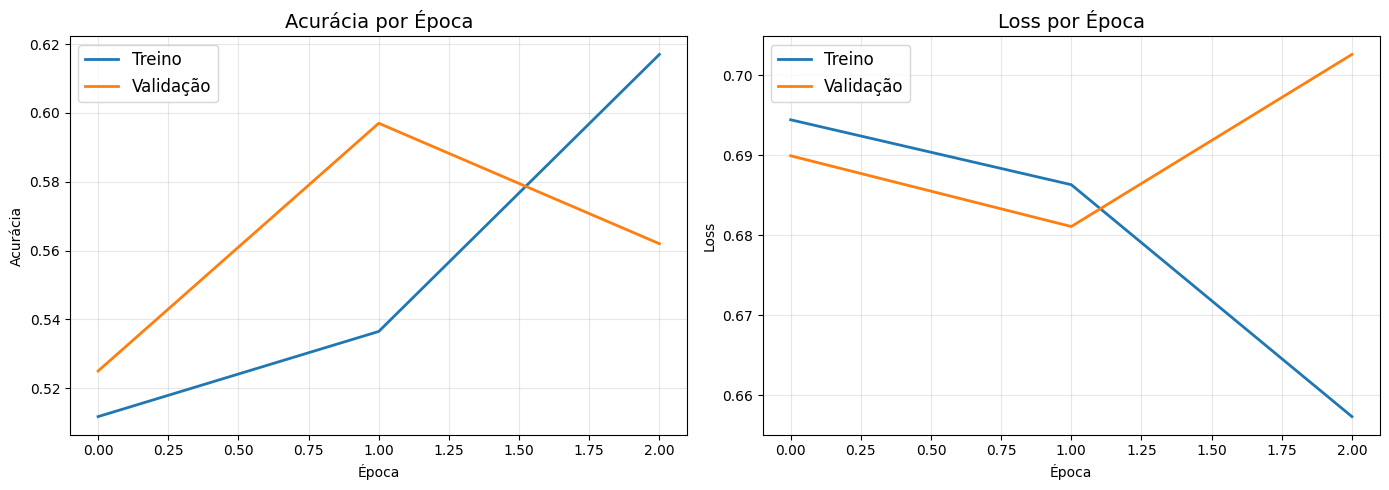


📊 Diagnóstico:
- Se treino >> validação → OVERFITTING (modelo memoriza, não generaliza)
- Se treino ≈ validação e ambos ruins → UNDERFITTING (modelo muito simples)
- Se treino ≈ validação e ambos bons → modelo OK!


In [ ]:
# ============================================================
# GRÁFICOS DE TREINAMENTO
# ============================================================
# Visualizamos como acurácia e loss evoluíram ao longo das épocas
# para diagnosticar overfitting ou underfitting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico de Acurácia ---
axes[0].plot(historico.history['accuracy'], label='Treino', linewidth=2)
axes[0].plot(historico.history['val_accuracy'], label='Validação', linewidth=2)
axes[0].set_title('Acurácia por Época', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# --- Gráfico de Loss ---
axes[1].plot(historico.history['loss'], label='Treino', linewidth=2)
axes[1].plot(historico.history['val_loss'], label='Validação', linewidth=2)
axes[1].set_title('Loss por Época', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Diagnóstico:")
print("- Se treino >> validação → OVERFITTING (modelo memoriza, não generaliza)")
print("- Se treino ≈ validação e ambos ruins → UNDERFITTING (modelo muito simples)")
print("- Se treino ≈ validação e ambos bons → modelo OK!")

---

## 8️⃣ Predição de Novas Imagens

### O pipeline de predição

Para classificar uma nova imagem, precisamos seguir **exatamente** o mesmo pré-processamento que foi feito no treinamento:

```
1. Carregar a imagem  →  image.load_img(path, target_size=(64,64))
2. Converter para array  →  image.img_to_array(img)
3. Normalizar [0,1]  →  array /= 255
4. Adicionar dimensão batch  →  np.expand_dims(array, axis=0)
5. Predizer  →  modelo.predict(array)
6. Interpretar  →  < 0.5 = cachorro, ≥ 0.5 = gato
```

### Por que o `expand_dims`?

O modelo espera receber um **batch** de imagens, mesmo que seja uma só. O shape esperado é `(batch_size, 64, 64, 3)`. Quando carregamos 1 imagem, o shape é `(64, 64, 3)`. O `expand_dims` adiciona a dimensão do batch: `(1, 64, 64, 3)`.

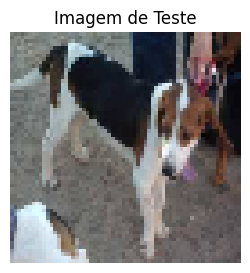

Tipo: <class 'PIL.Image.Image'>


In [ ]:
# ============================================================
# PREDIÇÃO PASSO A PASSO — Imagem do conjunto de teste
# ============================================================

# Passo 1: Carregar a imagem e redimensionar para 64×64
# (o modelo foi treinado com imagens 64×64, então PRECISA ser o mesmo tamanho)
caminho_teste = f'{temp_dir.name}/dataset/test_set/cachorro/dog.3500.jpg'
imagem_teste = image.load_img(caminho_teste, target_size=(64, 64))

# Visualizando a imagem carregada
plt.figure(figsize=(3, 3))
plt.imshow(imagem_teste)
plt.title('Imagem de Teste')
plt.axis('off')
plt.show()

print(f"Tipo: {type(imagem_teste)}")

In [ ]:
# Passo 2: Converter imagem PIL para array numpy
# Cada pixel vira 3 valores (R, G, B) de 0 a 255
imagem_teste = image.img_to_array(imagem_teste)

print(f"Shape após img_to_array: {imagem_teste.shape}")
print(f"Valores: {imagem_teste.min():.0f} a {imagem_teste.max():.0f}")

Shape após img_to_array: (64, 64, 3)
Valores: 0 a 255


In [ ]:
# Passo 3: Normalizar dividindo por 255
# IMPORTANTE: o modelo foi treinado com rescale=1./255, então
# na predição TAMBÉM precisamos normalizar da mesma forma
imagem_teste /= 255

print(f"Shape após normalização: {imagem_teste.shape}")
print(f"Valores agora: {imagem_teste.min():.4f} a {imagem_teste.max():.4f}")

Shape após normalização: (64, 64, 3)
Valores agora: 0.0000 a 1.0000


In [ ]:
# Passo 4: Adicionar dimensão do batch
# O modelo espera shape (batch, 64, 64, 3)
# Uma imagem tem shape (64, 64, 3)
# expand_dims adiciona a dimensão: (1, 64, 64, 3)
imagem_teste = np.expand_dims(imagem_teste, axis=0)

print(f"Shape final para predição: {imagem_teste.shape}")
print(f"  → batch_size=1, altura=64, largura=64, canais=3")

Shape final para predição: (1, 64, 64, 3)
  → batch_size=1, altura=64, largura=64, canais=3


In [ ]:
# Passo 5: Fazer a predição
# O modelo retorna um valor entre 0 e 1 (Sigmoid)
previsao = classificador.predict(imagem_teste)

print(f"Saída do modelo (valor bruto): {previsao[0][0]:.6f}")
print(f"\nInterpretação:")
print(f"  < 0.5 → Cachorro (classe 0)")
print(f"  ≥ 0.5 → Gato (classe 1)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Saída do modelo (valor bruto): 0.324377

Interpretação:
  < 0.5 → Cachorro (classe 0)
  ≥ 0.5 → Gato (classe 1)


In [ ]:
# Passo 6: Interpretar a predição
valor = previsao[0][0]
classe_predita = "Gato" if valor >= 0.5 else "Cachorro"
confianca = valor if valor >= 0.5 else (1 - valor)

print(f"Predição: {classe_predita}")
print(f"Confiança: {confianca*100:.1f}%")

Predição: Cachorro
Confiança: 67.6%


---

## 9️⃣ Função de Predição Reutilizável

Vamos encapsular todo o pipeline de predição em uma função para facilitar o uso e testar com várias imagens.

In [ ]:
# ============================================================
# FUNÇÃO DE PREDIÇÃO COMPLETA
# ============================================================
# Encapsula todos os 6 passos em uma única chamada

def predict_image(caminho, mostrar_imagem=True):
    """
    Classifica uma imagem como Gato ou Cachorro.

    Parâmetros:
        caminho (str): caminho completo para a imagem .jpg/.png
        mostrar_imagem (bool): se True, exibe a imagem com o resultado

    Retorna:
        str: 'Cachorro' ou 'Gato'
    """
    # Passo 1: Carrega e redimensiona para 64×64
    img = image.load_img(caminho, target_size=(64, 64))

    # Passo 2: Converte para array numpy
    img_array = image.img_to_array(img)

    # Passo 3: Normaliza para [0, 1]
    img_array /= 255

    # Passo 4: Adiciona dimensão do batch
    img_array = np.expand_dims(img_array, axis=0)

    # Passo 5: Predição
    valor = classificador.predict(img_array, verbose=0)[0][0]

    # Passo 6: Interpretação
    classe = "Gato" if valor >= 0.5 else "Cachorro"
    confianca = valor if valor >= 0.5 else (1 - valor)

    # Visualização (opcional)
    if mostrar_imagem:
        img_original = image.load_img(caminho, target_size=(128, 128))
        plt.figure(figsize=(3, 3))
        plt.imshow(img_original)
        cor = 'green' if confianca > 0.7 else 'orange'
        plt.title(f'{classe} ({confianca*100:.1f}%)', fontsize=14, color=cor, fontweight='bold')
        plt.axis('off')
        plt.show()

    return classe

In [ ]:
# ============================================================
# TESTANDO COM IMAGENS DO CONJUNTO DE TESTE
# ============================================================

# Teste com cachorro
resultado = predict_image(f'{temp_dir.name}/dataset/test_set/cachorro/dog.3500.jpg')
print(f"Resultado: {resultado}")

In [ ]:
# Teste com gato
resultado = predict_image(f'{temp_dir.name}/dataset/test_set/gato/cat.3500.jpg')
print(f"Resultado: {resultado}")

In [ ]:
# ============================================================
# PREDIÇÃO EM LOTE — Várias imagens de uma vez
# ============================================================
# Vamos testar com 10 imagens de cada classe para ver a performance

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Acertos e erros
acertos = 0
total = 0

for row, (classe_real, pasta) in enumerate([('Cachorro', 'cachorro'), ('Gato', 'gato')]):
    classe_path = os.path.join(f'{temp_dir.name}/dataset/test_set', pasta)
    arquivos = sorted([f for f in os.listdir(classe_path) if f.endswith(('.jpg', '.jpeg', '.png'))])

    for col in range(5):
        img_path = os.path.join(classe_path, arquivos[col + 10])  # Pega imagens diferentes das anteriores

        # Predição
        img = image.load_img(img_path, target_size=(64, 64))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)
        valor = classificador.predict(img_arr, verbose=0)[0][0]

        pred = "Gato" if valor >= 0.5 else "Cachorro"
        correto = pred == classe_real
        acertos += int(correto)
        total += 1

        # Visualização
        img_show = image.load_img(img_path, target_size=(128, 128))
        axes[row, col].imshow(img_show)
        cor = 'green' if correto else 'red'
        axes[row, col].set_title(f'Real: {classe_real}\nPred: {pred}', fontsize=10, color=cor)
        axes[row, col].axis('off')

plt.suptitle(f'Predições em Lote — Acertos: {acertos}/{total} ({acertos/total*100:.0f}%)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 🔟 Visualizando o que a CNN Aprendeu

Vamos extrair e visualizar os **filtros aprendidos** pela primeira camada convolucional e os **mapas de ativação** para entender o que a rede "enxerga".

In [ ]:
# ============================================================
# FILTROS APRENDIDOS (1ª camada convolucional)
# ============================================================
# Os filtros são os "detectores de padrões" que a CNN aprendeu
# Cada filtro tem shape (3, 3, 3) → 3×3 pixels, 3 canais RGB

filtros, biases = classificador.layers[1].get_weights()  # layers[1] = Conv2D (layers[0] = InputLayer)

print(f"Shape dos filtros: {filtros.shape}")
print(f"  → {filtros.shape[3]} filtros de {filtros.shape[0]}×{filtros.shape[1]} com {filtros.shape[2]} canais")

# Normaliza filtros para visualização [0, 1]
f_min, f_max = filtros.min(), filtros.max()
filtros_norm = (filtros - f_min) / (f_max - f_min)

# Plota os 32 filtros (cada um é uma imagem 3×3 RGB)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(32):
    # Cada filtro tem 3 canais (RGB) — exibimos a média dos canais
    filtro_i = filtros_norm[:, :, :, i]
    axes[i].imshow(filtro_i, interpolation='nearest')
    axes[i].set_title(f'F{i+1}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('32 Filtros Aprendidos (1ª Camada Convolucional)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Cada filtro detecta um padrão diferente (bordas, cores, texturas).")
print("A rede aprendeu SOZINHA quais filtros são úteis para distinguir gatos de cachorros!")

In [ ]:
# ============================================================
# MAPAS DE ATIVAÇÃO — o que cada filtro "vê" na imagem
# ============================================================
# Passamos uma imagem pela rede e extraímos a saída da 1ª camada Conv2D

# Modelo auxiliar que retorna ativações da 1ª camada convolucional
modelo_ativacao = tf.keras.Model(
    inputs=classificador.input,
    outputs=classificador.layers[1].output  # Saída da 1ª Conv2D
)

# Carrega uma imagem e processa
img_ativ = image.load_img(f'{temp_dir.name}/dataset/test_set/gato/cat.3500.jpg', target_size=(64, 64))
img_ativ_array = image.img_to_array(img_ativ) / 255.0
img_ativ_array = np.expand_dims(img_ativ_array, axis=0)

# Obtém as ativações
ativacoes = modelo_ativacao.predict(img_ativ_array, verbose=0)

print(f"Shape das ativações: {ativacoes.shape}")
print(f"  → {ativacoes.shape[3]} mapas de ativação de {ativacoes.shape[1]}×{ativacoes.shape[2]}")

# Plota: imagem original + primeiros 15 mapas de ativação
fig, axes = plt.subplots(2, 8, figsize=(18, 5))

# Imagem original
axes[0, 0].imshow(img_ativ)
axes[0, 0].set_title('Original', fontsize=10, fontweight='bold')
axes[0, 0].axis('off')

# Mapas de ativação
idx = 0
for i in range(2):
    start = 1 if i == 0 else 0
    for j in range(start, 8):
        if idx >= 15:
            axes[i, j].axis('off')
            continue
        axes[i, j].imshow(ativacoes[0, :, :, idx], cmap='viridis')
        axes[i, j].set_title(f'Mapa {idx+1}', fontsize=9)
        axes[i, j].axis('off')
        idx += 1

plt.suptitle('Mapas de Ativação — o que cada filtro detecta na imagem do gato', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

---

## 📋 Resumo da Aula

### O que fizemos:

| Etapa | O que aprendemos |
|-------|------------------|
| Representação | Imagens coloridas são matrizes H×W×3 (RGB), cada valor de 0 a 255 |
| Carregamento | `flow_from_directory` lê imagens de pastas e infere classes automaticamente |
| Data Augmentation | Gera variações das imagens (rotação, flip, zoom) para combater overfitting |
| Arquitetura CNN | Conv2D → BatchNorm → MaxPool → Conv2D → BatchNorm → MaxPool → Flatten → Dense → Sigmoid |
| Treinamento | Adam + binary_crossentropy para classificação binária |
| Predição | Pipeline: load → array → normalize → expand_dims → predict → interpret |
| Visualização | Filtros aprendidos e mapas de ativação mostram o que a CNN "enxerga" |

### Diferenças entre Fashion MNIST e Gatos/Cachorros:

| Aspecto | Fashion MNIST | Gatos/Cachorros |
|---------|--------------|------------------|
| Resolução | 28×28 | 64×64 |
| Canais | 1 (cinza) | 3 (RGB) |
| Pixels por imagem | 784 | 12.288 |
| Classes | 10 | 2 (binário) |
| Ativação saída | Softmax | Sigmoid |
| Loss | categorical_crossentropy | binary_crossentropy |
| Data Augmentation | Não usado | Essencial (dataset menor) |

### Próximos passos:

- **Transfer Learning**: usar uma CNN pré-treinada (VGG16, ResNet) como base para obter acurácia > 90% com poucas imagens
- **Aumentar épocas e resolução**: treinar por mais tempo com imagens maiores (128×128 ou 224×224)
- **Mais filtros**: adicionar mais camadas convolucionais ou aumentar o número de filtros